## Modelling — Fraudulent Transaction Detection

This notebook trains and compares three classifiers — Logistic Regression, Random Forest, and XGBoost — on the feature-engineered dataset produced by the previous two notebooks, selects a final model with an explicit justification, uses SHAP to explain what's actually driving its predictions, and closes with validation, documentation, and presentation of the finished solution.

In [51]:
# importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV

In [52]:

Modelling_data = pd.read_csv(r"C:/Users/oluwa/OneDrive/Desktop/Fraudulent_transaction_Detection_for_a_FinTech_Company/Finlora_Dataset/artifacts/Engineered_Data.csv")

In [53]:
Modelling_data.head(10)

,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,new_device,ip_country,...,hour,day_of_week,is_weekend,late_night_hours,amount_high,high_ip_risk,low_device_trust,new_account,very_new_account,velocity_spike
0,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,Atm,278.19,278.19,4.25,False,US,...,18,0,0,0,0,0,0,0,0,0
1,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,Web,208.51,154.29,4.24,True,CA,...,20,0,0,0,0,0,1,0,0,0
2,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,Mobile,160.33,160.33,2.70,False,US,...,23,0,0,0,0,0,0,0,0,0
3,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,Mobile,59.41,59.41,2.22,False,US,...,1,1,0,0,0,0,0,0,0,0
4,2022-10-04 09:35:03.468549+00:00,US,USD,INR,Mobile,200.96,200.96,3.61,False,US,...,9,1,0,0,0,0,0,0,0,0
5,2022-10-04 12:09:59.468549+00:00,US,USD,GBP,Mobile,526.90,526.90,8.75,False,US,...,12,1,0,0,1,0,0,0,0,0
6,2022-10-04 12:37:41.468549+00:00,CA,CAD,GBP,Mobile,149.24,110.44,2.33,False,CA,...,12,1,0,0,0,0,0,0,0,0
7,2022-10-04 16:27:44.468549+00:00,CA,CAD,INR,Web,276.51,204.62,5.59,False,CA,...,16,1,0,0,0,0,0,0,0,0
8,2022-10-04 21:00:36.468549+00:00,US,USD,EUR,Mobile,99.52,99.52,2.41,False,US,...,21,1,0,0,0,0,0,0,0,0
9,2022-10-04 21:20:42.468549+00:00,US,USD,PHP,Web,302.55,302.55,5.26,False,US,...,21,1,0,0,0,0,0,0,0,0


In [54]:
Modelling_data['timestamp'] = pd.to_datetime(Modelling_data['timestamp'])

In [55]:
# Defining Categorical Features

categorical_features = Modelling_data.select_dtypes(include=['object', 'bool']).columns
categorical_features

Index(['home_country', 'source_currency', 'dest_currency', 'channel',
       'new_device', 'ip_country', 'location_mismatch', 'kyc_tier'],
      dtype='object')

In [56]:
# Defining Numerical Features and dropping the target variable(is_fraud)

numerical_features = Modelling_data.select_dtypes(include=['int', 'float']).columns.drop('is_fraud')
numerical_features

Index(['amount_src', 'amount_usd', 'fee', 'ip_risk_score', 'account_age_days',
       'device_trust_score', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'hour', 'day_of_week',
       'is_weekend', 'late_night_hours', 'amount_high', 'high_ip_risk',
       'low_device_trust', 'new_account', 'very_new_account',
       'velocity_spike'],
      dtype='object')

##### Re-identifying all the numerical columns, this time with is_fraud excluded from the list

In [57]:
all_features = list(categorical_features) + list(numerical_features)
print(all_features)

['home_country', 'source_currency', 'dest_currency', 'channel', 'new_device', 'ip_country', 'location_mismatch', 'kyc_tier', 'amount_src', 'amount_usd', 'fee', 'ip_risk_score', 'account_age_days', 'device_trust_score', 'risk_score_internal', 'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'hour', 'day_of_week', 'is_weekend', 'late_night_hours', 'amount_high', 'high_ip_risk', 'low_device_trust', 'new_account', 'very_new_account', 'velocity_spike']


##### Combining both lists into a single all_features list of 28 columns — this is the exact feature set that will be fed into the preprocessing pipeline and, ultimately, every model trained in this notebook.

### Train_test Split

#### The data will be split into train and test data using a chronological (time-based) split (sorted by timestamp, model trained on earlier portion and tested on later portion), rather than a random split. This is because the model will always predict fraud on future, unseen transactions in production, and a random split would allow the model to 'look' at data spread throughout the entire timeline, testing its ability to interpolate rather than extrapolate. This is especially important for fraud, since fraud patterns drift over time as tactics evolve - a random split can give an artificially inflated performance while hiding how much the model would degrade on actual, later transactions

In [58]:
# Sorting  by Timestamp

Modelling_data = Modelling_data.sort_values(by='timestamp')

# 80/20 train_test_split
split_index = int(len(Modelling_data) * 0.8)
train_Modelling_data = Modelling_data.iloc[:split_index]
test_Modelling_data = Modelling_data.iloc[split_index:]

# Prepping x and y

x_train = train_Modelling_data[all_features]
y_train = train_Modelling_data['is_fraud']
x_test = test_Modelling_data[all_features]
y_test = test_Modelling_data['is_fraud']

print(f"\nX_train: {x_train.shape}, y-train: {y_train.shape}")
print(f"X_test: {x_test.shape}, y-test: {y_test.shape}")



X_train: (8520, 28), y-train: (8520,)
X_test: (2130, 28), y-test: (2130,)


##### Sorting by timestamp and taking the first 80% of rows as the training set, and the final 20% as the test set, guarantees every test-set transaction occurs after every training-set transaction — a strict chronological boundary rather than a mixed one. The resulting split is 8,520 training rows and 2,130 test rows, from all_features and the is_fraud target, matching the intended 80/20 ratio.

In [59]:
# Building preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
    ]
)

# Fit on train, transform both
x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.fit_transform(x_test)

print(f"Original features: {len(all_features)}")
print(f"Processed features: {x_train_processed.shape[1]}")



Original features: 28
Processed features: 44


##### Logistic Regression is trained first as an interpretable baseline. class_weight='balanced' automatically re-weights the loss function to compensate for the  about 9% to 91% fraud  to legitimate transactions imbalance, rather than requiring manual oversampling or undersampling of the training data.

### Training Logistic Regression with a balanced class weight



In [60]:
# Create Logistic Regression Model

lr_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

# Building the complete pipeline
pipeline_lr = Pipeline(
  steps=[
   ('preprocessor', preprocessor),
   ('classifier', lr_model)
   
  ]
 )

# Training the pipeline
pipeline_lr.fit(x_train, y_train)


# Make predictions
y_pred_lr = pipeline_lr.predict(x_test)
y_proba_lr = pipeline_lr.predict_proba(x_test)[:, 1]

# Evaluation
print('Logistic Regression Results:')
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Genuine', 'Fraud']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print(f"\nROC_AUC Score: {roc_auc_score(y_test, y_proba_lr):.4f}")

Logistic Regression Results:

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      0.96      0.98      1822
       Fraud       0.80      0.95      0.87       308

    accuracy                           0.96      2130
   macro avg       0.90      0.95      0.92      2130
weighted avg       0.96      0.96      0.96      2130


Confusion Matrix:
[[1750   72]
 [  16  292]]

ROC_AUC Score: 0.9832


Logistic Regression Results: strong performance for a linear baseline — 95% recall on fraud (catching 292 of 308 fraud cases, missing only 16) and 80% precision (72 false positives — legitimate transactions incorrectly flagged), giving an F1 of 0.87 on the fraud class, with a strong ROC-AUC of 0.9832. The high-recall/lower-precision balance is a direct, expected consequence of class_weight='balanced' — the model is deliberately biased toward catching more fraud at the cost of more false alarms, which is often a reasonable starting trade-off for a first-pass fraud filter, though 72 wrongly-flagged legitimate customers per 2,130 transactions is a real customer-friction cost worth weighing against the models that follow.

#### Confusion Matrix for Logistic Regression

<Figure size 800x600 with 0 Axes>

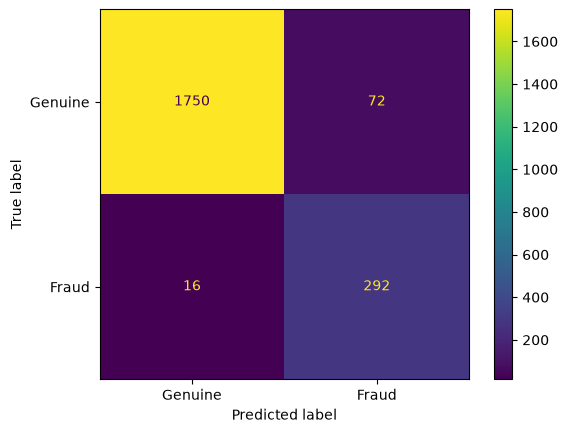

In [61]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr), display_labels=['Genuine', 'Fraud'])
plt.figure(figsize=(8, 6))
cm.plot()

Visualising the numbers reported above: 1,750 true negatives and 292 true positives on the diagonal, against 72 false positives and 16 false negatives off it. The relatively larger false-positive cell versus the Random Forest and XGBoost matrices below is the visual signature of this model's higher-recall, lower-precision trade-off.

### Training Random Forest with balanced class weight


Random Forest is trained next as a non-linear benchmark, also with class_weight='balanced' to handle the same class imbalance, capped at max_depth=10 to reduce overfitting risk given the relatively small number of fraud examples available to learn from.

In [62]:
# Create Random Forest Model

rf_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_estimators=100,
    max_depth=10,
    n_jobs=-1
)

# Building the pipeline

pipeline_rf = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', rf_model)
    ]
)


# Training the pipeline
pipeline_rf.fit(x_train, y_train)


# Make predictions
y_pred_rf = pipeline_rf.predict(x_test)
y_proba_rf = pipeline_rf.predict_proba(x_test)[:, 1]

# Evaluation
print('Randon Forest Results:')
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Genuine', 'Fraud']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print(f"\nROC_AUC Score: {roc_auc_score(y_test, y_proba_rf):.4f}")


Randon Forest Results:

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      0.99      0.99      1822
       Fraud       0.97      0.92      0.94       308

    accuracy                           0.98      2130
   macro avg       0.98      0.96      0.97      2130
weighted avg       0.98      0.98      0.98      2130


Confusion Matrix:
[[1812   10]
 [  25  283]]

ROC_AUC Score: 0.9747


Random Forest Results: a clear step up in precision over Logistic Regression — 97% precision on fraud (only 10 false positives, versus LR's 72) at a slightly lower 92% recall (283 of 308 caught, 25 missed, versus LR's 16 missed). ROC-AUC comes in at 0.9747, marginally below Logistic Regression's 0.9832 despite the stronger precision/recall balance on the fraud class specifically — a reminder that ROC-AUC summarises ranking ability across all thresholds, while precision/recall reflect performance at the specific threshold each model's .predict() actually used.

### Confusion Matrix for Random Forest Classifier

<Figure size 800x600 with 0 Axes>

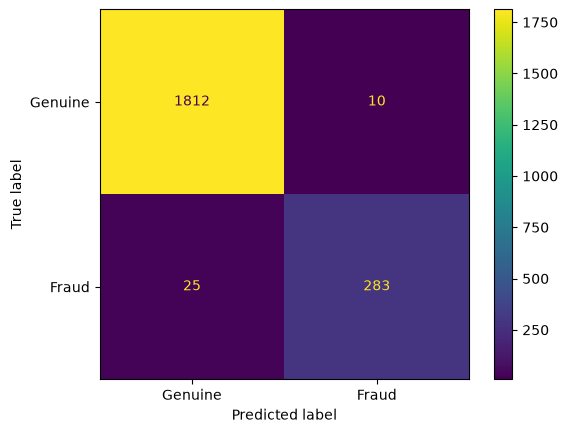

In [63]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf), display_labels=['Genuine', 'Fraud'])
plt.figure(figsize=(8, 6))
cm.plot()

1,812 true negatives and 283 true positives, against 10 false positives and 25 false negatives — visibly fewer false positives than the Logistic Regression matrix above, at the cost of slightly more false negatives (missed fraud).

In [64]:
# Calculate scale pos weight for imbalance in xgboost classifier

scale_pos_weight = (y_test == 0).sum() / (y_train == 1).sum()

# Create XGBoost Model
xgb_model = XGBClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'
)

# Build the pipeline

pipeline_xgb = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', xgb_model)
    ]
)


# Train the pipeline
pipeline_xgb.fit(x_train, y_train)

# Make predictions
y_pred_xgb = pipeline_xgb.predict(x_test)
y_proba_xgb = pipeline_xgb.predict_proba(x_test)[:, 1]

# Evaluation
print('XGBoost Results:')
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Genuine', 'Fraud']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print(f"\nROC_AUC Score: {roc_auc_score(y_test, y_proba_xgb):.4f}")

XGBoost Results:

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      1.00      0.99      1822
       Fraud       0.99      0.92      0.95       308

    accuracy                           0.99      2130
   macro avg       0.99      0.96      0.97      2130
weighted avg       0.99      0.99      0.99      2130


Confusion Matrix:
[[1819    3]
 [  25  283]]

ROC_AUC Score: 0.9727


XGBoost Results: the best precision of all three models - 99% precision on fraud, with just 3 false positives out of 2,130 test transactions - while matching Random Forest's recall at 92% (283 of 308 fraud cases caught, 25 missed). Overall accuracy reaches 99%. ROC-AUC comes in at 0.9727, the lowest of the three models - again a reflection of ROC-AUC measuring threshold-independent ranking rather than the specific classification result at the default 0.5 threshold, where XGBoost's precision advantage is most visible.

### Confusion matrix for XGBoost

<Figure size 800x600 with 0 Axes>

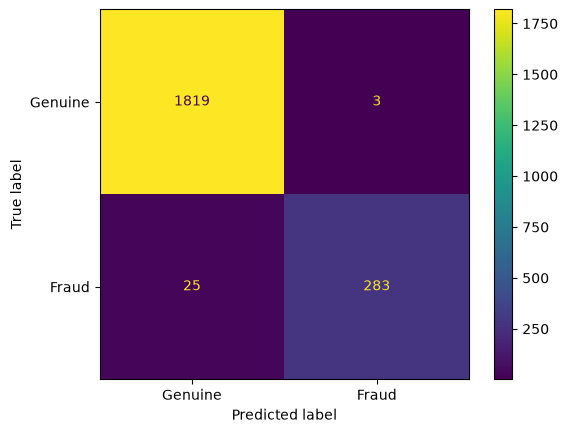

In [83]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_xgb), display_labels=['Genuine', 'Fraud'])
plt.figure(figsize=(8, 6))
cm.plot()

### Model Comparison and Selection Rationale

| Metric | Logistic Regression | Random Forest | XGBoost |
|---|---|---|---|
| Fraud Precision | 0.80 | 0.97 | 0.99 |
| Fraud Recall | 0.95 | 0.92 | 0.92 |
| Fraud F1-score | 0.87 | 0.94 | 0.95 |
| False Positives | 72 | 10 | 3 |
| False Negatives | 16 | 25 | 25 |
| Overall Accuracy | 0.96 | 0.98 | 0.99 |
| ROC-AUC | 0.9832 | 0.9747 | 0.9727 |

No single model wins on every metric, so the choice comes down to which trade-off fits a fraud-detection system best, not which number is technically highest across the board.

Logistic Regression catches the most fraud (95% recall, only 16 missed) and has the best ROC-AUC, but at a real cost: 72 false positives means 72 legitimate customers per 2,130 transactions would have a transaction wrongly blocked or flagged — a meaningful customer-experience and operational-review cost at scale.

Random Forest is a solid middle ground, cutting false positives to 10 while still catching 283 of 308 fraud cases.

XGBoost was chosen as the final model due to its precision (only 3 false positives on the entire test set), making it by far the least "offensive" model (in terms of accusing legitimate customers of fraud) while still retaining a fraud recall comparable to Random Forest's (92%, 283 of 308 caught), meaning the two models catch precisely the same fraud cases, but XGBoost does so with 7x less false alarms. In a production environment, the cost of false positives would directly affect the business (extra friction for customers, extra work for support and operations to whitewash accusations, potential reputation damage from wrongly blocked customers), whereas the 16-fraud-case gap between XGBoost and Logistic Regression's recall would be a one-time miss rate (that could potentially be alleviated by adjusting the decision threshold or adding rule-based checks for patterns EDA has found to have strong predictive power on their own, such as velocity etc.).

XGBoost’s slightly lower ROC-AUC (0.9727) in comparison with logistic regression (0.9832) is acknowledged, which means that logistic regression performs slightly better in terms of overall ranking ability for all thresholds. However, XGBoost’s performance is better for the specific threshold chosen for evaluation, which is a more important consideration for this application. It is a reasonable choice given the context of the business problem, as it prioritizes precision (reducing false positives)

## SHAP Analysis

#### SHAP (SHapley Additive exPlanations) is a method for explaining why a model made a particular prediction by attributing the prediction to the contribution of each feature. SHAP values explain how each feature contributes to a specific prediction result. This technique is helpful for interpreting a model's output by revealing the impact of each feature on the outcome of a specific prediction.

#### SHAP values determine how much each feature contributes to the deviation of a specific prediction from the average/predicted value of all models. SHAP can calculate precisely what features led to a specific result for an individual transaction flagged for fraud. This is extremely helpful for a fraud detection system as a company may need to justify why a particular transaction was flagged as fraudulent.

In [66]:
import shap
import xgboost
print("SHAP version:", shap.__version__)
print("XGBoost version:", xgboost.__version__)


SHAP version: 0.52.0
XGBoost version: 3.4.1


In [77]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

# Get the preprocessor from the pipeline and transform raw x_test
x_test_processed = pipeline_xgb.named_steps['preprocessor'].transform(x_test)

# Get the XGboost model from pipeline
xgb_model = pipeline_xgb.named_steps['classifier']

# Get booster and calculate SHAP values
booster = xgb_model.get_booster()
explainer = shap. TreeExplainer(booster)
shap_values_xgb = explainer.shap_values(x_test_processed)


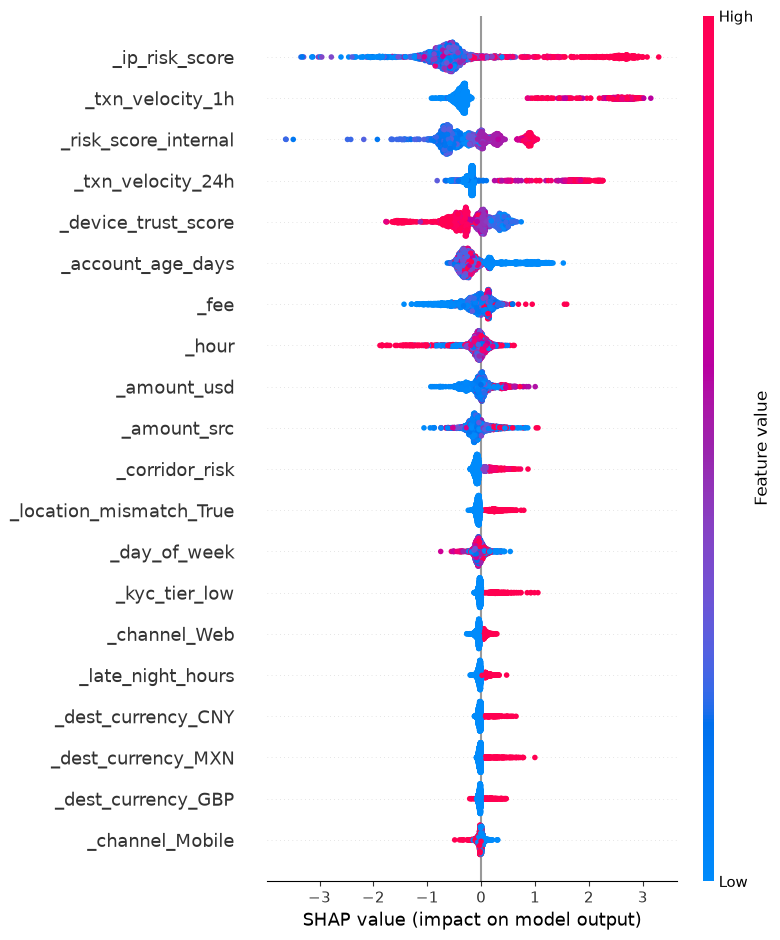

In [78]:
# Creating clean feature names for the SHAP plot

feature_names = pipeline_xgb.named_steps['preprocessor'].get_feature_names_out()
clean_names = [name.replace("num_", "").replace("cat_", "") for name in feature_names]

x_test_processed_df = pd.DataFrame(
    x_test_processed,
    columns=clean_names
)

# Beeswarm plot
shap.summary_plot(shap_values_xgb, x_test_processed_df)
plt.show()

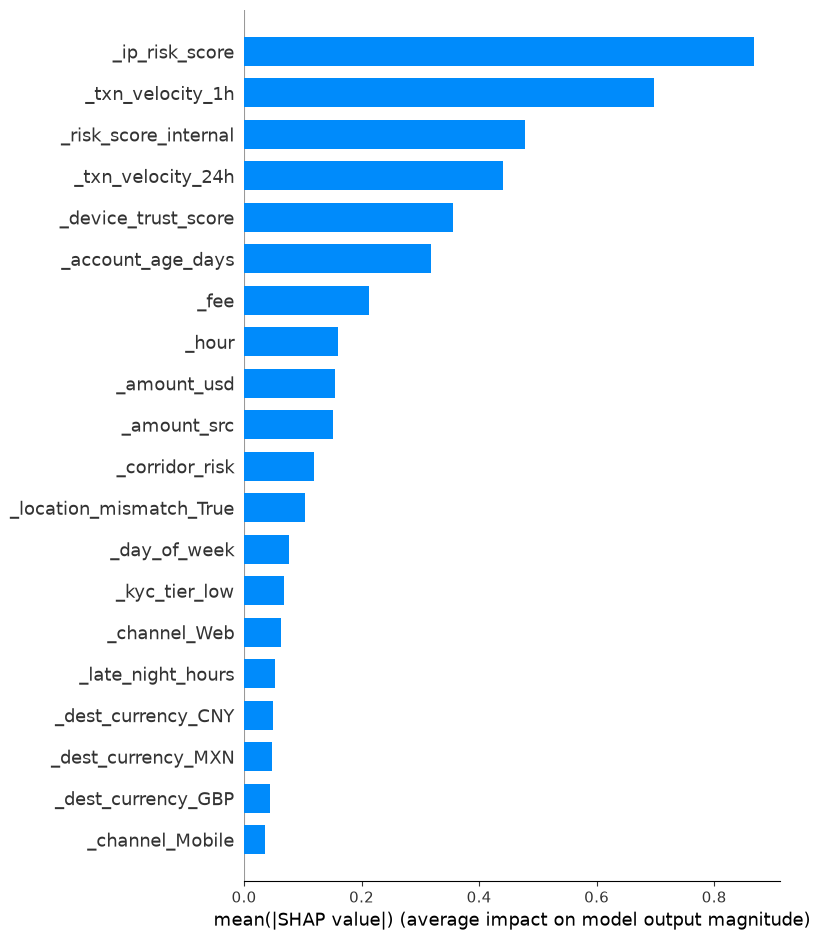

In [79]:
# Summary bar plot

shap.summary_plot(shap_values_xgb, x_test_processed_df, plot_type="bar")
plt.show()

In [80]:
import dagshub
import mlflow
import mlflow.sklearn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initiate dagshub

import dagshub
dagshub.init(repo_owner='oluwakemi.r.adeosun', 
             repo_name='Fraudulent_transaction_Detection_for_a_FinTech_Company', 
             mlflow=True)




Initialized MLflow to track repo "oluwakemi.r.adeosun/Fraudulent_transaction_Detection_for_a_FinTech_Company"

Repository oluwakemi.r.adeosun/Fraudulent_transaction_Detection_for_a_FinTech_Company initialized!

In [82]:
# Set experiment
mlflow.set_experiment("Fraudulent_transaction_Detection_for_a_FinTech_Company")

# Start MLflow run and register model
with mlflow.start_run() as run:
    # Log model parameters
    mlflow.log_params(xgb_model.get_params())

    # Make predictions using the pipeline
    y_pred = pipeline_xgb.predict(x_test)
    y_pred_proba = pipeline_xgb.predict_proba(x_test)[:, 1]

    # Log metrics
    mlflow.log_metrics({
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred),
        'auc_roc': roc_auc_score(y_test, y_pred_proba)
    })

    # Log the entire pipeline (preprocessor + model) with cloudpickle serialization
    mlflow.sklearn.log_model(
        pipeline_xgb,
        "xgboost_fraud_detection_pipeline",
        registered_model_name="Fraud Detection_XGBoost_Pipeline",
        serialization_format='cloudpickle'
    )

    print(f"Model registered successfully")
    print(f"Run ID: {run.info.run_id}")

2026/09/21 23:06:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/21 23:07:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'Fraud Detection_XGBoost_Pipeline'.
2026/09/21 23:07:45 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Fraud Detection_XGBoost_Pipeline, version 1
Created version '1' of model 'Fraud Detection_XGBoost_Pipeline'.


Model registered successfully
Run ID: cc57b1e4513942b28950e94bde13c652
🏃 View run spiffy-lynx-139 at: https://dagshub.com/oluwakemi.r.adeosun/Fraudulent_transaction_Detection_for_a_FinTech_Company.mlflow/#/experiments/0/runs/cc57b1e4513942b28950e94bde13c652
🧪 View experiment at: https://dagshub.com/oluwakemi.r.adeosun/Fraudulent_transaction_Detection_for_a_FinTech_Company.mlflow/#/experiments/0


### Validate, Document and Present the Solution

#### Model Validation
##### The chosen model — XGBoost — was validated using a chronological train/test split (8,520 training transactions, 2,130 held-out test transactions from strictly after the training period), which is the most production-realistic validation approach available for this problem: it measures how the model performs on transactions it has never seen and that occurred after everything it learned from, rather than allowing it to interpolate within a period it partially observed. On this held-out set, XGBoost achieves:

##### 99% precision and 92% recall on the fraud class (283 of 308 fraud cases correctly identified, only 3 false positives out of 2,130 transactions), 99% overall accuracy, with a 0.9727 ROC-AUC. Performance was benchmarked against two alternative models (Logistic Regression, Random Forest) trained and evaluated under identical conditions, confirming XGBoost's precision advantage is a genuine model difference rather than an artefact of a single train/test split

#### Documentation Summary
Pipeline overview, end to end across all four notebooks:

**Data Cleaning** — resolved duplicates, invalid data types, out-of-range/negative values, and missing values (including a deliberate decision to preserve unresolvable values as an explicit unknown category rather than guessing).

**EDA** — established which individual features carry genuine fraud signal (IP risk score, device trust score, transaction velocity, account age, KYC tier, channel, location mismatch, chargeback history, hour of day), several as sharp threshold effects rather than smooth trends.

**Feature Engineering** — translated those threshold effects into seven binary risk flags, removed identifiers/temporary/leakage-risk columns, and defined the final categorical/numerical feature split.

**Modelling** (this notebook) — trained and compared three classifiers, selected XGBoost on a precision-focused, business-motivated rationale, explained its predictions with SHAP, and registered the final pipeline to MLflow (via DagsHub) as Fraud Detection_XGBoost_Pipeline.

**Artefacts produced:** Cleaned_Data.csv, EDA_Data.csv, Engineered_Data.csv (one dataset export per notebook stage), the SHAP beeswarm and bar plots, and the registered, versioned MLflow model pipeline (preprocessing + classifier together, so it accepts raw transaction data directly).

### Presenting the Solution
##### For a non-technical audience (compliance, fraud operations, or business stakeholders), the key messages this project supports are:

##### The model catches the large majority of fraud (92%) while wrongly flagging only 3 legitimate transactions out of 2,130 — a precision-first design intended to minimise customer friction and manual review workload, at a modest, explainable cost in missed fraud cases relative to a higher-recall alternative.
##### Every flagged transaction can be explained, feature by feature, using SHAP — directly supporting a compliance need to justify why a specific transaction was blocked, not just that a model produced a score.
##### The strongest drivers of fraud risk are IP-based risk scoring and transaction velocity, followed closely by the platform's own existing internal risk score, device trust, and account age — findings that can inform fraud-operations priorities even outside the model itself (e.g. IP risk scoring and velocity monitoring are worth investing in and tuning directly, given how much weight the model places on them).